# Mini-Project 4: Rainfall Pattern & Crop Suitability Analyser

**Scenario.** An agricultural extension officer wants to compare rainfall regimes across regions and advise farmers on which months suit which crops.

**My approach** (classes in `src/rainfall.py`):
* `Region`: the 12 monthly totals plus summary methods and season (peak) detection.
* `CropRule`: a crop's suitable monthly rainfall band, derived from a cited seasonal water requirement.
* `SimilarityAnalyser`: builds cosine / Pearson / Euclidean matrices for every pair of regions.

**Assumptions.** The core analysis uses the *illustrative* data from the brief. For the extension (and extra credit) I replace it with **real NASA POWER monthly rainfall for 2014–2023** and check whether the conclusions change.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path

from src.rainfall import (MONTHS, CropRule, Region, SimilarityAnalyser, climatology,
                          cosine_similarity, fetch_nasa_power_monthly,
                          scipy_cosine_similarity, suitability_table)

pd.set_option("display.float_format", "{:,.3f}".format)
plt.rcParams.update({"figure.dpi": 110})

## Task 1: The `Region` class

In [2]:
RAW = {
    "Kampala": [120, 140, 180, 200, 220, 180,  90,  70,  60, 100, 110, 130],
    "Gulu":    [  8,  25,  75, 160, 190, 145, 170, 215, 175, 150,  60,  15],
    "Mbarara": [ 70,  85, 120, 140,  90,  25,  20,  55, 100, 125, 120,  90],
}
regions = [Region(name, rain) for name, rain in RAW.items()]
summary = pd.DataFrame([{
    "region": r.name, "annual total (mm)": r.annual_total(), "monthly mean (mm)": r.mean(),
    "wettest": r.wettest_month(), "driest": r.driest_month(), "CV": r.coefficient_of_variation(),
} for r in regions]).set_index("region")
summary

,annual total (mm),monthly mean (mm),wettest,driest,CV
region,,,,,
Kampala,"1,600.000",133.333,May,Sep,0.388
Gulu,"1,388.000",115.667,Aug,Jan,0.642
Mbarara,"1,040.000",86.667,Apr,Jul,0.444


Gulu has the highest CV (≈ 0.64). Its rain is concentrated in one long wet period, with a very dry December–February. Kampala has the most evenly spread rain (CV ≈ 0.39). Mbarara is the driest region overall but sits in between on CV.

## Task 2: `CropRule` with cited thresholds

Agronomic sources give a crop's water need for its **whole growing period**. `CropRule.from_seasonal_need` spreads that need evenly over the months of the season to get a monthly band. A month below the band is a **drought risk**; a month above it is a **waterlogging risk** (excess water the crop cannot use, which risks root rot and disease in beans and nutrient leaching in maize).

| Crop | Seasonal water need | Season length used | Monthly band | Source |
|---|---|---|---|---|
| Maize | 500–800 mm | 4.5 months (125–180 days) | ≈ 111–178 mm | Brouwer & Heibloem (1986), FAO Irrigation Water Management Training Manual 3, Table 3 |
| Beans | 300–500 mm | 3.5 months (95–110 days) | ≈ 86–143 mm | Brouwer & Heibloem (1986), Table 3 |
| Banana (matooke) | 1,200–2,200 mm/yr | 12 months | 100–183 mm | Brouwer & Heibloem (1986), Table 3 |
| Coffee (Arabica) | 1,200–1,800 mm/yr optimum | 12 months | 100–150 mm | DaMatta & Ramalho (2006), *Braz. J. Plant Physiol.* 18(1): 55–81 |

In [3]:
FAO = "Brouwer & Heibloem (1986) FAO Irrigation Water Management Training Manual 3, Table 3"
crops = [
    CropRule.from_seasonal_need("Maize", 500, 800, 4.5, FAO),
    CropRule.from_seasonal_need("Beans", 300, 500, 3.5, FAO),
    CropRule.from_seasonal_need("Banana", 1200, 2200, 12, FAO),
    CropRule.from_seasonal_need("Coffee", 1200, 1800, 12, "DaMatta & Ramalho (2006)"),
]
for c in crops:
    print(f"{c.crop:7s} {c.min_mm:6.1f} - {c.max_mm:6.1f} mm/month   [{c.source}]")

Maize    111.1 -  177.8 mm/month   [Brouwer & Heibloem (1986) FAO Irrigation Water Management Training Manual 3, Table 3]
Beans     85.7 -  142.9 mm/month   [Brouwer & Heibloem (1986) FAO Irrigation Water Management Training Manual 3, Table 3]
Banana   100.0 -  183.3 mm/month   [Brouwer & Heibloem (1986) FAO Irrigation Water Management Training Manual 3, Table 3]
Coffee   100.0 -  150.0 mm/month   [DaMatta & Ramalho (2006)]


In [4]:
table = suitability_table(regions, crops)
status = table.pivot_table(index=["region", "crop"], columns="month", values="status",
                           aggfunc="first", sort=False)[list(MONTHS)]
status

month                       Jan              Feb                Mar  \
region  crop                                                          
Kampala Maize    Good for maize   Good for maize  Waterlogging risk   
        Beans    Good for beans   Good for beans  Waterlogging risk   
        Banana  Good for banana  Good for banana    Good for banana   
        Coffee  Good for coffee  Good for coffee  Waterlogging risk   
Gulu    Maize      Drought risk     Drought risk       Drought risk   
        Beans      Drought risk     Drought risk       Drought risk   
        Banana     Drought risk     Drought risk       Drought risk   
        Coffee     Drought risk     Drought risk       Drought risk   
Mbarara Maize      Drought risk     Drought risk     Good for maize   
        Beans      Drought risk     Drought risk     Good for beans   
        Banana     Drought risk     Drought risk    Good for banana   
        Coffee     Drought risk     Drought risk    Good for coffee   

month                         Apr                May                Jun  \
region  crop                                                              
Kampala Maize   Waterlogging risk  Waterlogging risk  Waterlogging risk   
        Beans   Waterlogging risk  Waterlogging risk  Waterlogging risk   
        Banana  Waterlogging risk  Waterlogging risk    Good for banana   
        Coffee  Waterlogging risk  Waterlogging risk  Waterlogging risk   
Gulu    Maize      Good for maize  Waterlogging risk     Good for maize   
        Beans   Waterlogging risk  Waterlogging risk  Waterlogging risk   
        Banana    Good for banana  Waterlogging risk    Good for banana   
        Coffee  Waterlogging risk  Waterlogging risk    Good for coffee   
Mbarara Maize      Good for maize       Drought risk       Drought risk   
        Beans      Good for beans     Good for beans       Drought risk   
        Banana    Good for banana       Drought risk       Drought risk   
        Coffee    Good for coffee       Drought risk       Drought risk   

month                         Jul                Aug                Sep  \
region  crop                                                              
Kampala Maize        Drought risk       Drought risk       Drought risk   
        Beans      Good for beans       Drought risk       Drought risk   
        Banana       Drought risk       Drought risk       Drought risk   
        Coffee       Drought risk       Drought risk       Drought risk   
Gulu    Maize      Good for maize  Waterlogging risk     Good for maize   
        Beans   Waterlogging risk  Waterlogging risk  Waterlogging risk   
        Banana    Good for banana  Waterlogging risk    Good for banana   
        Coffee  Waterlogging risk  Waterlogging risk  Waterlogging risk   
Mbarara Maize        Drought risk       Drought risk       Drought risk   
        Beans        Drought risk       Drought risk     Good for beans   
        Banana       Drought risk       Drought risk    Good for banana   
        Coffee       Drought risk       Drought risk    Good for coffee   

month                         Oct              Nov              Dec  
region  crop                                                         
Kampala Maize        Drought risk     Drought risk   Good for maize  
        Beans      Good for beans   Good for beans   Good for beans  
        Banana    Good for banana  Good for banana  Good for banana  
        Coffee    Good for coffee  Good for coffee  Good for coffee  
Gulu    Maize      Good for maize     Drought risk     Drought risk  
        Beans   Waterlogging risk     Drought risk     Drought risk  
        Banana    Good for banana     Drought risk     Drought risk  
        Coffee    Good for coffee     Drought risk     Drought risk  
Mbarara Maize      Good for maize   Good for maize     Drought risk  
        Beans      Good for beans   Good for beans   Good for beans  
        Banana    Good for banana  Good for banana     Drought 

In [5]:
good_months = (table[table["score"] == 0].groupby(["region", "crop"], sort=False)["month"]
               .apply(lambda m: ", ".join(m)).unstack())
print("Months classified as suitable:")
good_months

Months classified as suitable:


crop,Maize,Beans,Banana,Coffee
region,,,,
Kampala,"Jan, Feb, Dec","Jan, Feb, Jul, Oct, Nov, Dec","Jan, Feb, Mar, Jun, Oct, Nov, Dec","Jan, Feb, Oct, Nov, Dec"
Gulu,"Apr, Jun, Jul, Sep, Oct",NaN,"Apr, Jun, Jul, Sep, Oct","Jun, Oct"
Mbarara,"Mar, Apr, Oct, Nov","Mar, Apr, May, Sep, Oct, Nov, Dec","Mar, Apr, Sep, Oct, Nov","Mar, Apr, Sep, Oct, Nov"


## Task 3: Correcting last year's cosine-similarity method

`math.cos(x)` returns the cosine of an **angle x in radians**. Passing it rainfall numbers gives meaningless values (e.g. `math.cos(120)` ≈ 0.81 but `math.cos(121)` ≈ −0.05: a 1 mm change in rain flips the "similarity"). Cosine *similarity* is the cosine of the **angle between two vectors**, computed from the vectors themselves:

$$\cos\theta = \frac{\mathbf{a}\cdot\mathbf{b}}{\lVert\mathbf{a}\rVert\,\lVert\mathbf{b}\rVert}$$

`scipy.spatial.distance.cosine` returns the cosine **distance** = 1 − similarity, so I compare against 1 − distance.

In [6]:
import math
print("Old (wrong) approach: math.cos(120), math.cos(121) =", round(math.cos(120), 3), round(math.cos(121), 3))
for i in range(len(regions)):
    for j in range(i + 1, len(regions)):
        a, b = regions[i], regions[j]
        ours, ref = cosine_similarity(a.rainfall, b.rainfall), scipy_cosine_similarity(a.rainfall, b.rainfall)
        manual = np.dot(a.rainfall, b.rainfall) / (np.linalg.norm(a.rainfall) * np.linalg.norm(b.rainfall))
        print(f"{a.name:8s} vs {b.name:8s}: ours = {ours:.6f}  scipy = {ref:.6f}  manual = {manual:.6f}  match = {np.isclose(ours, ref)}")

Old (wrong) approach: math.cos(120), math.cos(121) = 0.814 -0.049
Kampala  vs Gulu    : ours = 0.786609  scipy = 0.786609  manual = 0.786609  match = True
Kampala  vs Mbarara : ours = 0.891250  scipy = 0.891250  manual = 0.891250  match = True
Gulu     vs Mbarara : ours = 0.748678  scipy = 0.748678  manual = 0.748678  match = True


## Task 4: Similarity and distance matrices

In [7]:
sa = SimilarityAnalyser(regions)
for title, m in [("Cosine similarity", sa.cosine()), ("Pearson correlation", sa.pearson()),
                 ("Euclidean distance (mm)", sa.euclidean())]:
    print(title)
    display(m.round(3))

Cosine similarity


,Kampala,Gulu,Mbarara
Kampala,1.000,0.787,0.891
Gulu,0.787,1.000,0.749
Mbarara,0.891,0.749,1.000


Pearson correlation


,Kampala,Gulu,Mbarara
Kampala,1.000,-0.066,0.209
Gulu,-0.066,1.000,-0.174
Mbarara,0.209,-0.174,1.000


Euclidean distance (mm)


,Kampala,Gulu,Mbarara
Kampala,0.000,315.268,250.400
Gulu,315.268,0.000,312.800
Mbarara,250.400,312.800,0.000


In [8]:
# Why cosine can call a much wetter region "similar": scale has no effect on the angle.
k = regions[0].rainfall
print("cosine(Kampala, 2 x Kampala)    =", round(cosine_similarity(k, 2 * k), 4))
print("Pearson(Kampala, 2 x Kampala)   =", round(np.corrcoef(k, 2 * k)[0, 1], 4))
print("Euclidean(Kampala, 2 x Kampala) =", round(np.linalg.norm(k - 2 * k), 1), "mm")
# And because rainfall is never negative, cosine can't go below 0 and is inflated by the shared positive 'offset':
print("cosine(Kampala, flat 133 mm/month) =", round(cosine_similarity(k, np.full(12, k.mean())), 3))

cosine(Kampala, 2 x Kampala)    = 1.0
Pearson(Kampala, 2 x Kampala)   = 1.0
Euclidean(Kampala, 2 x Kampala) = 492.7 mm
cosine(Kampala, flat 133 mm/month) = 0.937


**Interpretation.**
* **Cosine similarity** is high for every pair (0.75–0.89). Kampala and Mbarara score 0.89 even though Kampala gets 50 % more rain. Cosine measures only the *angle* between the vectors, so multiplying one region's rainfall by any positive factor leaves it unchanged: Kampala vs a region with twice Kampala's rain scores exactly 1.0. Rainfall is also never negative, so all vectors point into the same "positive" region of space and the similarity is inflated. Even a completely flat, seasonless rainfall profile scores about 0.94 against Kampala.
* **Pearson correlation** is cosine similarity *after subtracting each region's mean*. It therefore compares the timing of wet and dry months. It is much more discriminating: Kampala–Gulu is ≈ −0.07 (their seasons do not line up), Kampala–Mbarara is ≈ 0.21 (both have a March–May season).
* **Euclidean distance** compares absolute amounts (mm) and so is sensitive to *both* timing and wetness. Gulu is about 310 mm away from both others.

For crop advice, timing *and* amount both matter, so cosine on raw totals is the least useful of the three. That is a second flaw in last year's method, beyond the `math.cos` bug.

## Task 5: Automatic season detection with `scipy.signal.find_peaks`

Two details matter for monthly climatology data:
1. **Wrap-around.** December is adjacent to January. I tile the year three times, detect peaks, and keep those in the middle copy, so a peak in December or January is not lost at the array edge.
2. **Prominence.** With 12 noisy points, any small bump is a "peak". I count a peak as a separate rainy season only if its **prominence is at least 25 % of that region's annual range** (max − min). Making it relative keeps the rule comparable between wet and dry regions.

In [9]:
rows = []
for r in regions:
    proms = r.peak_prominences()
    rows.append({"region": r.name,
                 "local peaks (relative prominence)": ", ".join(f"{m} ({p:.2f})" for m, p in proms.items()),
                 "seasons detected": ", ".join(MONTHS[i] for i in r.detect_peaks(0.25)),
                 "modality (threshold 0.25)": r.modality(0.25)})
peaks = pd.DataFrame(rows).set_index("region")
display(peaks)

sens = pd.DataFrame({t: [r.modality(t) for r in regions] for t in [0.05, 0.10, 0.20, 0.25, 0.30, 0.50]},
                    index=[r.name for r in regions])
sens.columns.name = "relative prominence threshold"
print("Sensitivity of the classification to the threshold:")
sens

,local peaks (relative prominence),seasons detected,modality (threshold 0.25)
region,,,
Kampala,"May (1.00), Dec (0.06)",May,unimodal
Gulu,"May (0.22), Aug (1.00)",Aug,unimodal
Mbarara,"Apr (1.00), Oct (0.46)","Apr, Oct",bimodal


Sensitivity of the classification to the threshold:


relative prominence threshold,0.050,0.100,0.200,0.250,0.300,0.500
Kampala,bimodal,unimodal,unimodal,unimodal,unimodal,unimodal
Gulu,bimodal,bimodal,bimodal,unimodal,unimodal,unimodal
Mbarara,bimodal,bimodal,bimodal,bimodal,bimodal,unimodal


**Does this match Uganda's known climate zones?** Published descriptions of Uganda's climate (e.g. UNMA seasonal outlooks; the World Bank Climate Change Knowledge Portal) describe a **bimodal** regime over the Lake Victoria basin and the south-west (long rains March–May, short rains September–November) and a **unimodal** regime in the north (one long season from about April to October/November).

| Region | Known regime | Detected (illustrative data) | Agrees? |
|---|---|---|---|
| Mbarara (south-west) | bimodal | bimodal (Apr and Oct peaks) | ✅ |
| Gulu (north) | unimodal, often with a slight mid-season dip | unimodal: the May bump has prominence 0.22, below the 0.25 threshold | ✅ (borderline) |
| Kampala (L. Victoria basin) | bimodal | **unimodal**: the December bump has prominence only 0.06 | ❌ |

The Kampala mismatch comes from the **data**, not the method. In the illustrative series, January–February are wet (120–140 mm), so the short rains run straight into the long rains and there is no December–February dry season to separate them. Real Kampala climatology has a clear dry spell in January–February (see the extension below, where the same algorithm correctly finds two seasons). Gulu shows how fragile the threshold is: anything below 0.22 would call it bimodal. With only 12 monthly points, any peak-based classification needs a stated, justified threshold and should be checked against more years of data.

## Task 6: Visualisations

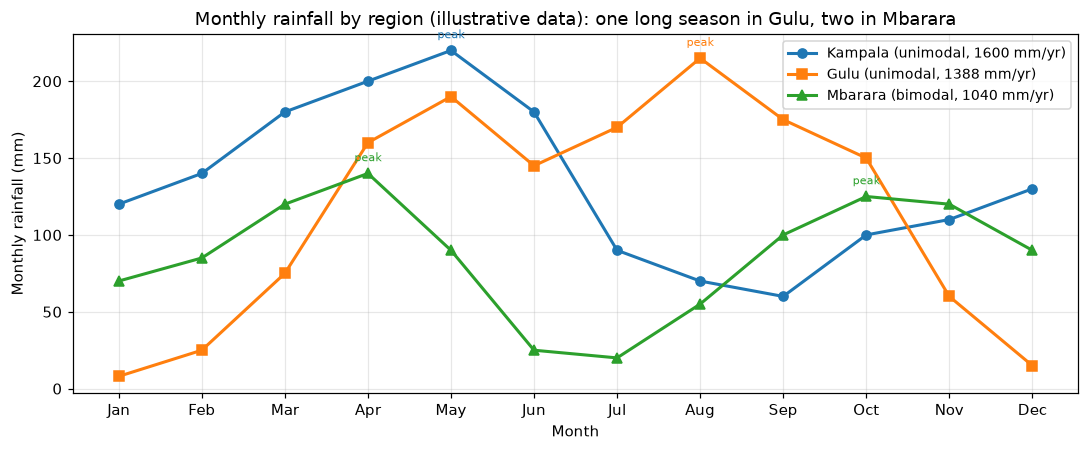

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.2))
styles = {"Kampala": ("tab:blue", "o"), "Gulu": ("tab:orange", "s"), "Mbarara": ("tab:green", "^")}
x = np.arange(12)
for r in regions:
    col, mk = styles[r.name]
    ax.plot(x, r.rainfall, marker=mk, color=col, lw=2, label=f"{r.name} ({r.modality()}, {r.annual_total():.0f} mm/yr)")
    for p in r.detect_peaks():
        ax.annotate("peak", (p, r.rainfall[p]), xytext=(0, 8), textcoords="offset points",
                    ha="center", fontsize=7, color=col)
ax.set_xticks(x, MONTHS)
ax.set_xlabel("Month")
ax.set_ylabel("Monthly rainfall (mm)")
ax.set_title("Monthly rainfall by region (illustrative data): one long season in Gulu, two in Mbarara")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig("figures/p4_rainfall_lines.png", bbox_inches="tight")
plt.show()

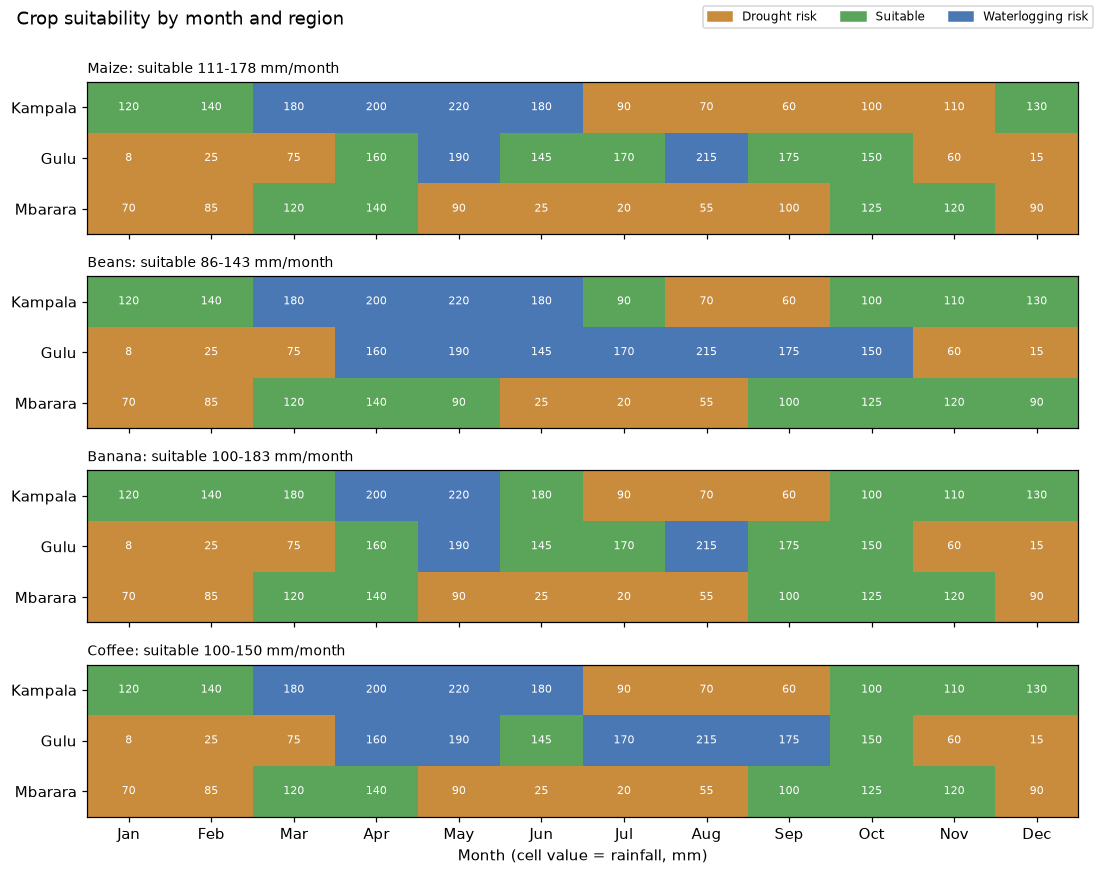

In [11]:
cmap = ListedColormap(["#c98b3c", "#5aa55a", "#4a78b5"])   # drought / good / waterlogging
fig, axes = plt.subplots(len(crops), 1, figsize=(10, 1.45 * len(crops) * len(regions) / 2.2), sharex=True)
for ax, crop in zip(axes, crops):
    grid = np.array([[crop.score(v) for v in r.rainfall] for r in regions])
    ax.imshow(grid, cmap=cmap, vmin=-1, vmax=1, aspect="auto")
    for i, r in enumerate(regions):
        for j in range(12):
            ax.text(j, i, f"{r.rainfall[j]:.0f}", ha="center", va="center", fontsize=7, color="white")
    ax.set_yticks(range(len(regions)), [r.name for r in regions])
    ax.set_title(f"{crop.crop}: suitable {crop.min_mm:.0f}-{crop.max_mm:.0f} mm/month", loc="left", fontsize=9)
axes[-1].set_xticks(range(12), MONTHS)
axes[-1].set_xlabel("Month (cell value = rainfall, mm)")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in cmap.colors]
fig.legend(handles, ["Drought risk", "Suitable", "Waterlogging risk"], loc="upper right", ncol=3, fontsize=8)
fig.suptitle("Crop suitability by month and region", x=0.02, ha="left", y=1.0)
fig.tight_layout()
fig.savefig("figures/p4_suitability_heatmap.png", bbox_inches="tight")
plt.show()

The heatmap shows at a glance that **Gulu and Mbarara have long drought-risk blocks** (Nov–Mar in Gulu; Jun–Aug and Dec–Feb in Mbarara). Kampala's long rains are *too wet* for beans, maize and coffee in March–June under these thresholds.

## Task 7: Advisory note for farmers in Mbarara (≤ 200 words)

> **Planting advice for Mbarara farmers**
>
> Mbarara has **two rainy seasons**: March–April and September–November. Between them come a sharp dry spell in **June–August** and a milder one in December–February.
>
> **Best crop: beans.** Beans mature in about three months and need moderate rain, so they fit both seasons.
> * **Season A:** plant when the rains have properly started, around **early to mid-March**. Harvest in June, before the dry spell.
> * **Season B:** plant in **mid-September**. Harvest in December.
>
> Wait until the topsoil is moist to a hand's depth before planting. Do not plant in May or after mid-October: the crop would flower or fill pods in the dry months.
>
> **Maize** is riskier here. It needs 4–5 months, but only about two consecutive months (March–April or October–November) have enough rain. If you grow maize, use an **early-maturing variety** and plant at the very start of the rains.
>
> **Bananas and coffee** need water all year. Mulch heavily and dig water-harvesting trenches before June so they survive the June–August dry spell.
>
> *Based on average rainfall. Always check the UNMA seasonal forecast before planting.*

## Extension: real NASA POWER rainfall (2014–2023)

**Source:** NASA Langley Research Center, POWER Project (Prediction Of Worldwide Energy Resources), monthly point data, parameter `PRECTOTCORR_SUM` (bias-corrected precipitation total, mm/month), community `AG`, accessed 6 October 2026. The coordinates are each town's centre. I download once with `fetch_nasa_power_monthly` and cache the result in `data/`, so the notebook runs offline and reproducibly. Delete the CSV to refresh it.

Caveat: POWER precipitation is a *satellite/reanalysis* product at about 0.5° resolution (MERRA-2 corrected with satellite data), not rain-gauge data. It is good for seasonal shape but smooths out local extremes.

In [12]:
CACHE = Path("data/nasa_power_monthly_rainfall.csv")
SITES = {"Kampala": (0.3476, 32.5825), "Gulu": (2.7724, 32.2881), "Mbarara": (-0.6072, 30.6545)}
if CACHE.exists():
    real = pd.read_csv(CACHE)
else:   # only runs if the cache was deleted; needs internet
    real = pd.concat([fetch_nasa_power_monthly(n, la, lo, 2014, 2023) for n, (la, lo) in SITES.items()],
                     ignore_index=True)
    real.to_csv(CACHE, index=False)
print(real.groupby("region")["year"].agg(["min", "max", "count"]))
real_regions = [climatology(real, name) for name in SITES]
compare = pd.DataFrame([{
    "region": r.name, "annual (illustrative)": Region(r.name, RAW[r.name]).annual_total(),
    "annual (NASA mean)": r.annual_total(),
    "modality (illustrative)": Region(r.name, RAW[r.name]).modality(),
    "modality (NASA)": r.modality(),
    "peaks (NASA, rel. prominence)": ", ".join(f"{m} ({p:.2f})" for m, p in r.peak_prominences().items()),
    "Pearson r (illustrative vs NASA)": np.corrcoef(RAW[r.name], r.rainfall)[0, 1],
} for r in real_regions]).set_index("region")
compare

          min   max  count
region                    
Gulu     2014  2023    120
Kampala  2014  2023    120
Mbarara  2014  2023    120


,annual (illustrative),annual (NASA mean),modality (illustrative),modality (NASA),"peaks (NASA, rel. prominence)",Pearson r (illustrative vs NASA)
region,,,,,,
Kampala,"1,600.000","1,505.879",unimodal,bimodal,"Apr (0.84), Nov (1.00)",0.295
Gulu,"1,388.000","1,415.759",unimodal,bimodal,"May (0.26), Oct (1.00)",0.852
Mbarara,"1,040.000","1,313.749",bimodal,bimodal,"Apr (1.00), Oct (0.76)",0.886


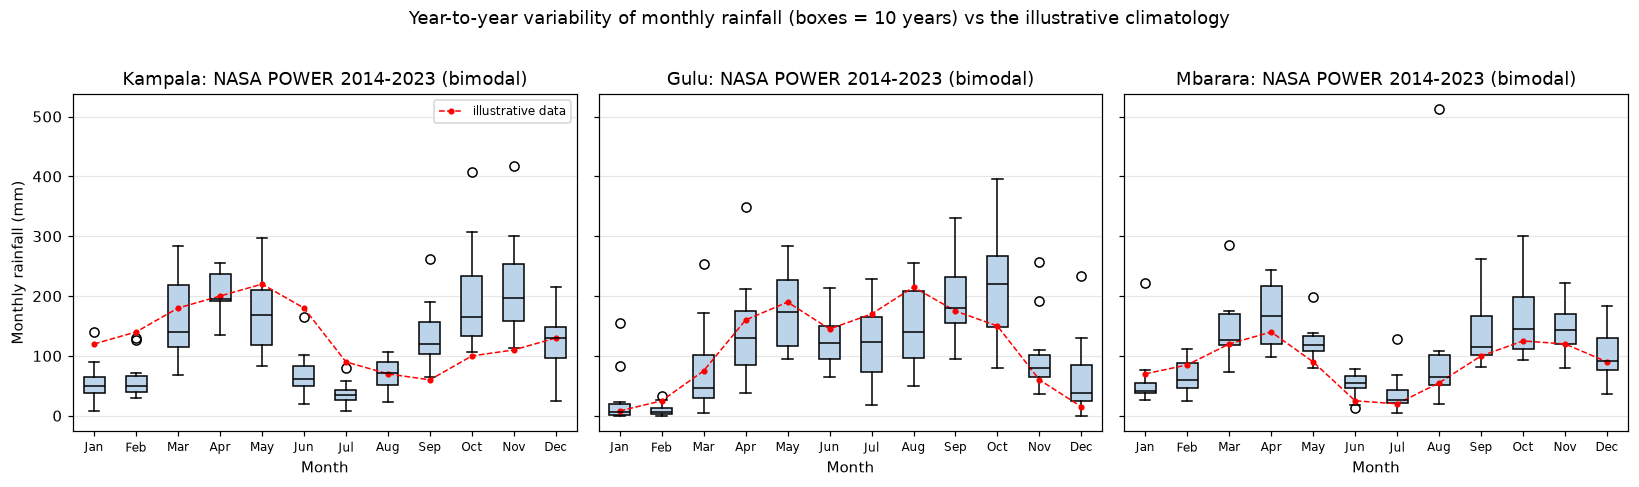

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), sharey=True)
for ax, name in zip(axes, SITES):
    sub = real[real["region"] == name]
    data = [sub.loc[sub["month"] == m, "rain_mm"].to_numpy() for m in range(1, 13)]
    ax.boxplot(data, tick_labels=MONTHS, patch_artist=True,
               boxprops=dict(facecolor="#bcd4ea"), medianprops=dict(color="black"))
    ax.plot(range(1, 13), RAW[name], "r--o", ms=3, lw=1, label="illustrative data")
    ax.set_title(f"{name}: NASA POWER 2014-2023 ({climatology(real, name).modality()})")
    ax.set_xlabel("Month")
    ax.tick_params(axis="x", labelsize=8)
    ax.grid(alpha=0.3, axis="y")
axes[0].set_ylabel("Monthly rainfall (mm)")
axes[0].legend(fontsize=8)
fig.suptitle("Year-to-year variability of monthly rainfall (boxes = 10 years) vs the illustrative climatology", y=1.02)
fig.tight_layout()
fig.savefig("figures/p4_nasa_boxplots.png", bbox_inches="tight")
plt.show()

In [14]:
# How often would a farmer following the illustrative-data advice actually get suitable rain?
beans = crops[1]
mb = real[real["region"] == "Mbarara"].copy()
mb["beans_ok"] = mb["rain_mm"].apply(lambda v: beans.score(v) == 0)
hit_rate = mb.groupby("month")["beans_ok"].mean().rename(index=dict(enumerate(MONTHS, 1)))
print("Share of years 2014-2023 in which each month was suitable for beans in Mbarara:")
print((hit_rate * 100).round(0).astype(int).astype(str).add("%").to_string())

Share of years 2014-2023 in which each month was suitable for beans in Mbarara:
month
Jan     0%
Feb    30%
Mar    50%
Apr    50%
May    80%
Jun     0%
Jul    10%
Aug    20%
Sep    60%
Oct    50%
Nov    40%
Dec    50%


**What the real data add.**
* With real data, **Kampala is clearly bimodal** (long rains peaking in April, short rains peaking in November), so the algorithm agrees with the known climate zones. This confirms that the Task 5 mismatch came from the illustrative data's wet January–February: the illustrative Kampala series correlates only r ≈ 0.30 with real Kampala rainfall, against r ≈ 0.85–0.89 for Gulu and Mbarara. Mbarara is also bimodal.
* **Gulu** now comes out as (weakly) bimodal: its May bump has prominence 0.26, just above the 0.25 threshold. That fits the north's "long season with a mid-season dip". In both datasets Gulu sits *on* the threshold, so I would report it as "unimodal with a mid-season break" and not trust the label alone.
* The box plots show large **year-to-year variability**. In the main rainy months, the spread between wet and dry years is often 100 mm or more, i.e. similar in size to a crop's entire monthly band. Advice based on a single average year therefore hides real risk. The hit-rate table quantifies this: in Mbarara's recommended bean months (March–April, September–October), rain fell inside the beans band in only about **half** of the ten years. The rest were too dry or too wet. That is a strong argument for using seasonal forecasts and drought-tolerant varieties rather than a fixed calendar.

## Findings & Limitations

**Findings.** The three regions differ less in total rain than in its *timing*. Mbarara and (in reality) Kampala have two rainy seasons, while Gulu has one long season with a mid-season dip, which the peak detector puts right on its threshold. Getting this right needed two fixes to the naïve approach: wrapping December to January, and a stated prominence rule. Last year's method had two errors. `math.cos` computes the cosine of an angle, not a vector similarity. And even correct cosine similarity on raw rainfall is a weak tool: it ignores scale, so a region with twice the rain looks identical, and it scores every pair highly because rainfall is never negative. Pearson correlation (for timing) together with Euclidean distance (for amount) separates the regions far better. For crops, beans are the best match for Mbarara's short, twice-yearly seasons; maize's 4–5-month need fits poorly there. The real NASA data confirm the seasonal patterns but reveal large year-to-year variability that a single climatology hides.

**Limitations.** The crop bands spread a seasonal water requirement evenly across months. Crops actually need little water at sowing and most at flowering, and the requirement is crop evapotranspiration, not rainfall: runoff, soil type and temperature decide how much rain is effective. "Waterlogging" above the band is a simplification, since drainage matters more than the monthly total. My citations give typical ranges, not Ugandan variety-specific values (NARO guidance would be better). With 12 points per region, season detection depends on the threshold. NASA POWER is coarse gridded data rather than station gauges.